# Wireless Coverage — Part 3: H3 Gridding of DEM / DSM / CHM Surfaces

> **Docs:** [Wireless Coverage — notebook series](https://databrickslabs.github.io/geobrix/docs/notebooks/wireless-coverage?flavor=notebooks)

![Wireless Coverage Part 3a — DEM/DSM/CHM surfaces to H3-indexed tables](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/wireless-coverage/wireless-coverage-03a.png)

This is where the series goes **beyond pixels**: the per-pixel surface rasters become a
discrete global grid, so cells align across DEM/DSM/CHM and join directly to the H3-indexed
tower analysis in Part 4. Prepare the LiDAR-derived elevation surfaces from Part 2a (or
Part 2b) for global-grid analysis by
H3-indexing each surface. DEM and DSM elevation bands are extracted as contiguous isoband
polygons (`rst_isoband`) and indexed to H3 cells with the Databricks product
`h3_try_coverash3`. The Canopy Height Model is aggregated to the maximum canopy height per
H3 cell (`gbx_rst_h3_rastertogridmax`). Gaps over land are filled with `h3_cellfill`
(k=1, IDW). The resulting H3 tables (`wc_h3_{dem,dsm,chm}_res10`) are prepared for
downstream coverage analysis — antenna siting and line-of-sight in Part 4.

Shared configuration (imports, params, helpers) is loaded via `%run ./config_nb` after
installation. Notebook-specific overrides follow the `%run` cell.

> **Runtime.** Runs on **Databricks Serverless environment 6** — the lightweight tier (pure
> Python/PySpark, no JAR or GDAL init script). Set `DEMO=True` (default) for a Golden Gate
> Park sub-AOI (~25 tiles) to iterate quickly; `DEMO=False` for full San Francisco.
> **H3 resolution:** 10 (≈ 65 m edge length — series default from `config_nb`).

---
**Last Update:** 2026-10-05


In [ ]:
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet \
  "geobrix[light_env6,vizx,stac,overture] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"


In [ ]:
%restart_python


In [0]:
%run ./config_nb

AOI EPSG:3857: x=[-13642204, -13619940] y=[4537132, 4558257]
Tile: 1024 m = 1024 px | H3_RESOLUTION = 10


In [0]:
# ── nb3-specific overrides (applied after %run ./config_nb) ─────────────────
# H3_RESOLUTION = 10 comes from config_nb (series default).
SRC_PREFIX   = "wc_surface"   # source tables from Part 2a/2b: wc_surface_{dsm,dtm,chm}
OUT_PREFIX   = "wc_h3"        # H3 output tables:  wc_h3_{dem,dsm,chm}_res{H3_RESOLUTION}
LAND_DIR     = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/overture-water-bay"
BREAKS_M     = [float(b) for b in range(0, 301, 30)]   # 10 elevation bands × 30 m
DEMO         = True
RENDER_H3    = True
INTERACTIVE  = False   # True → live deck.gl; False → static (GitHub-safe)
RUN_FULL_SF  = False   # True → also run the T9 full-SF scale-up/profiling (cells below)

> **Resolution is a choice, not a ceiling.** We grid at H3 resolution 10 here
> as a demo-friendly default — but the resolution is a dial. Part 1 already stored a res-15
> cell on every point (`cellid_r15`), so any step can roll up or down to *any* resolution via
> `h3_toparent` + a GROUP BY. H3 cells get finer than a raster pixel when you want: a res-15
> cell is ≈ 0.9 m² (sub-meter) versus ≈ 307 m² at res 12 and ≈ 15,000 m² at res 10.
> "Beyond pixels" is the DGGS paradigm — hierarchical, equal-area, globally addressable cells —
> not a coarser grid.


In [0]:
dsm = spark.table(_tbl(SRC_PREFIX, "dsm"))
dtm = spark.table(_tbl(SRC_PREFIX, "dtm"))
chm = spark.table(_tbl(SRC_PREFIX, "chm"))
print(f"Source surfaces: DSM {dsm.count()} | DTM {dtm.count()} | CHM {chm.count()} tiles")

# Confirm CRS (all should be EPSG:3857 — requires rst_transform before H3 indexing).
sample_srid = dsm.select(F.expr("gbx_rst_srid(dsm)").alias("srid")).first()["srid"]
assert sample_srid == 3857, f"Expected EPSG:3857, got {sample_srid}"
print(f"Surface CRS confirmed: EPSG:{sample_srid}")


Source surfaces: DSM 25 | DTM 25 | CHM 25 tiles
Surface CRS confirmed: EPSG:3857


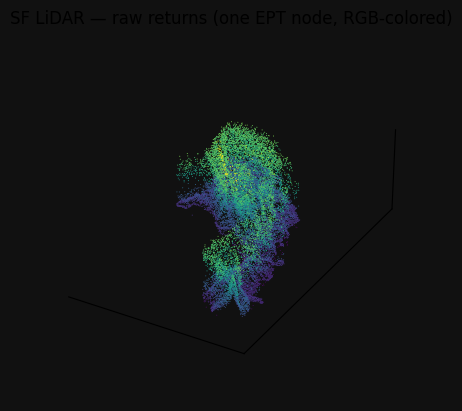

In [0]:
if RENDER_H3:
    laz_files = sorted(glob.glob(f"{LAZ_DIR}/**/*.laz", recursive=True))
    if laz_files:
        if INTERACTIVE:
            # Live deck.gl orbit view — Databricks interactive sessions only.
            plot_point_cloud(
                laz_files[0], color="rgb", max_points=150_000,
                title="SF LiDAR — raw returns (one EPT node, RGB-colored)",
            )
        else:
            # Static Axes3D scatter — image/png, GitHub-safe.
            plot_point_cloud(
                laz_files[0], color="rgb", max_points=150_000,
                max_embed_mb=0,
                title="SF LiDAR — raw returns (one EPT node, RGB-colored)",
            )
    else:
        print(f"No .laz staged under {LAZ_DIR}; point cloud preview skipped.")


In [0]:

if DEMO:
    _gx, _gy = lonlat_to_3857(-122.486, 37.769)   # Golden Gate Park centroid
    _tx, _ty = int((_gx - X0) / TILE_M), int((_gy - Y0) / TILE_M)
    DEMO_FILTER = (
        F.col("tx").between(_tx - 2, _tx + 2) &
        F.col("ty").between(_ty - 2, _ty + 2)
    )
    dtm_in = dtm.where(DEMO_FILTER)
    dsm_in = dsm.where(DEMO_FILTER)
    chm_in = chm.where(DEMO_FILTER)
    print(f"DEMO mode: {dtm_in.count()} DTM | {dsm_in.count()} DSM | {chm_in.count()} CHM tiles "
          f"in ±2 km window around Golden Gate Park (tx={_tx}, ty={_ty})")
else:
    dtm_in, dsm_in, chm_in = dtm, dsm, chm


DEMO mode: 25 DTM | 25 DSM | 25 CHM tiles in ±2 km window around Golden Gate Park (tx=6, ty=9)


## DEM / DSM surfaces → elevation isobands → H3 cells

Turns the EPSG:3857 DTM and DSM surfaces from Part 2a into elevation-band H3 cell tables
(`wc_h3_dem`, `wc_h3_dsm`). Key steps:

1. **Land mask** (Overture water features → SF land polygon) — clips Bay and Pacific
   pixels to NoData before isoband extraction.
2. **CRS transform**: `rst_transform(tile, 4326)` — `h3_try_coverash3` requires lon/lat WKB.
3. **`rst_clip`** — apply land mask to each reprojected tile.
4. **`rst_isoband`** — extract contiguous elevation-band polygons.
5. **`st_simplify`** (configurable) — trim isoband vertices to sharpen band seams; governed by `SIMPLIFY` config (default True).
6. **`h3_try_coverash3`** — index each band polygon to H3 cells (no driver-side indexing).
7. **Persist** both tables; print counts and band distribution.
8. **Cumulative tiers** and a static band map.

In [0]:
# --- Land mask: Overture base/water → SF land polygon ---
# Subtract Bay and Pacific water features from the AOI box to get a land multipolygon.
# Used as the rst_clip cutline to set water/ocean pixels to NoData before isoband.
ov = OvertureClient()
if not glob.glob(f"{LAND_DIR}/**/*.parquet", recursive=True):
    assets = ov.discover(SF_AOI, themes=["base"]).filter(F.col("type") == "water")
    ov.download(assets, LAND_DIR, bbox=SF_AOI)
water = ov.read(LAND_DIR, theme="base", type="water", bbox=SF_AOI)
_wg = [_wkb.loads(bytes(r["geometry"])) for r in water.select("geometry").collect()]
W, S, E, N = SF_AOI
land_geom = _box(W, S, E, N).difference(unary_union(_wg)) if _wg else _box(W, S, E, N)
land_wkb  = land_geom.wkb     # EPSG:4326 land multipolygon (WKB) — cutline for rst_clip
print(f"Land mask: subtracted {len(_wg)} water feature(s); "
      f"land area \u2248 {land_geom.area / _box(W,S,E,N).area:.2f} of AOI")


Land mask: subtracted 363 water feature(s); land area ≈ 0.50 of AOI


In [0]:
# --- Elevation-band H3 cells: EPSG:3857 surface tiles → H3 cells (EPSG:4326) ---
# breaks_arr is broadcast to every executor so each call to rst_isoband uses the
# same set of elevation thresholds.
breaks_arr = F.array(*[F.lit(b) for b in BREAKS_M])
# _surface_to_h3_cells(surface_df, tile_col, breaks_array, h3_res, land_wkb=None)
# → defined in config_nb; called with (surface_df, tile_col, breaks_arr, H3_RESOLUTION, land_wkb)


In [0]:
# --- Isoband validation: assert elevation bands are produced on a sample ---
# Fast pre-check before the full DEM/DSM passes — catches a misconfigured
# BREAKS_M or a mismatched CRS (e.g. tiles still in EPSG:3857 → all elevations
# fall outside the 0-300 m range → 0 bands). The flat Golden Gate Park DEMO
# window legitimately spans only about 2 elevation bands, so require ≥2 in
# DEMO and ≥3 at full-SF scale (where SF's relief guarantees several).
sample_tile = dtm_in.limit(5)
sample_cells = _surface_to_h3_cells(sample_tile, "dtm", breaks_arr, H3_RESOLUTION, land_wkb, simplify=SIMPLIFY)
band_counts = sample_cells.groupBy("band_level", "elev_lo", "elev_hi").count().orderBy("band_level")
band_counts.show()
n_nonempty = band_counts.count()
_min_bands = 2 if DEMO else 3
assert n_nonempty >= _min_bands, (
    f"Expected ≥{_min_bands} non-empty elevation bands, got {n_nonempty}. "
    "Check BREAKS_M range vs actual DTM elevation distribution."
)
print(f"Band validation: {n_nonempty} non-empty elevation bands (min {_min_bands}) — OK")

+----------+-------+-------+-----+
|band_level|elev_lo|elev_hi|count|
+----------+-------+-------+-----+
|         0|    0.0|   30.0|   63|
|         1|   30.0|   60.0|   44|
|         2|   60.0|   90.0|   22|
+----------+-------+-------+-----+

Band validation: 3 non-empty elevation bands (min 2) — OK


In [0]:
# --- Produce and persist wc_h3_dem (bare earth DTM elevation bands) ---
dem_cells = _surface_to_h3_cells(dtm_in, "dtm", breaks_arr, H3_RESOLUTION, land_wkb, simplify=SIMPLIFY)   # DEM = bare earth
dem_h3 = _persist(with_join_parent(dem_cells), "dem", res=H3_RESOLUTION)   # → geospatial_docs.geobrix.wc_h3_dem_res10
print(f"wc_h3_dem: {dem_h3.count()} rows (H3 res {H3_RESOLUTION})")
dem_h3.groupBy("band_level", "elev_lo", "elev_hi").count().orderBy("band_level").show()


wc_h3_dem: 1273 rows (H3 res 10)
+----------+-------+-------+-----+
|band_level|elev_lo|elev_hi|count|
+----------+-------+-------+-----+
|         0|    0.0|   30.0|  545|
|         1|   30.0|   60.0|  463|
|         2|   60.0|   90.0|  160|
|         3|   90.0|  120.0|   50|
|         4|  120.0|  150.0|   25|
|         5|  150.0|  180.0|   20|
|         6|  180.0|  210.0|   10|
+----------+-------+-------+-----+



In [0]:
# --- Produce and persist wc_h3_dsm (surface incl. buildings/canopy) ---
dsm_cells = _surface_to_h3_cells(dsm_in, "dsm", breaks_arr, H3_RESOLUTION, land_wkb, simplify=SIMPLIFY)   # DSM = surface incl. buildings/canopy
dsm_h3 = _persist(with_join_parent(dsm_cells), "dsm", res=H3_RESOLUTION)   # → geospatial_docs.geobrix.wc_h3_dsm_res10
print(f"wc_h3_dsm: {dsm_h3.count()} rows (H3 res {H3_RESOLUTION})")


wc_h3_dsm: 2002 rows (H3 res 10)


In [0]:
# --- DEM cumulative tiers: tier T = 'elevation >= BREAKS_M[T]' ---
# A cell in interval band i belongs to tiers 0..i; coverage depth climbs with
# terrain height — the telco nested-coverage model applied to elevation.
dem_tiers = (
    dem_h3
    .select("cellid", "res",
            F.explode(F.sequence(F.lit(0), F.col("band_level"))).alias("tier"))
    .distinct()
)
dem_tiers.groupBy("tier").count().orderBy("tier").show()


+----+-----+
|tier|count|
+----+-----+
|   0|  932|
|   1|  570|
|   2|  201|
|   3|   68|
|   4|   33|
|   5|   20|
|   6|   10|
+----+-----+



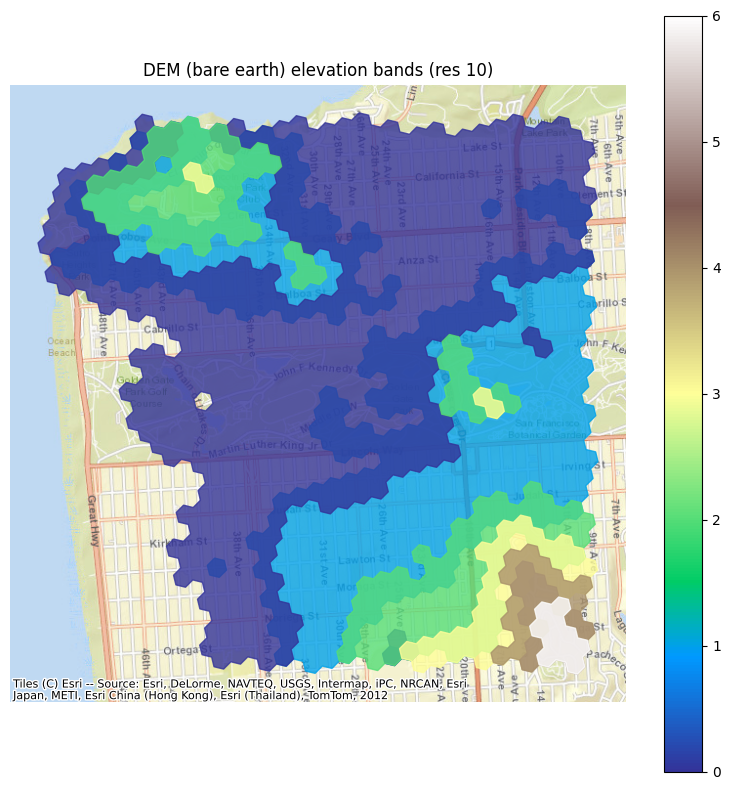

In [0]:
if RENDER_H3:
    # DEM bare-earth elevation bands. show_cell_map (config_nb): DEMO -> one Golden Gate Park map;
    # full SF -> one compact figure: SF res-9 overview + GGP detail (DETAIL_WINDOWS configurable).
    show_cell_map(spark.table(_tbl("wc_h3", "dem", H3_RESOLUTION)), "band_level",
                  "DEM (bare earth) elevation bands", dissolve_by="band_level", cmap="terrain")


## CHM → H3 max canopy height

The `gbx_rst_h3_rastertogridmax` UDTF aggregates all raster pixels whose centroid falls in
each H3 cell and returns the maximum value per cell. Applied to the CHM (canopy height in
metres), it gives the tallest vegetation or structure per H3 hexagon — the surface height
signal that nb4 will use for line-of-sight analysis.

**Scale note:** `DEMO=True` (default) runs on ~25 tiles (Golden Gate Park ±2 km); the full
San Francisco AOI is 336 CHM tiles (~336 M pixels at 1 m resolution). At res 10 over full SF,
expect 5–15 min on Serverless — profile with `DEMO=True` first and set `DEMO=False` when
the output is validated.


In [0]:
# rst_h3_rastertogridmax (and all H3 UDTFs) require lon/lat EPSG:4326 tiles.
chm_4326 = chm_in.select(
    "tx", "ty",
    rx.rst_transform("chm", F.lit(4326)).alias("chm_4326"),
)
# Register as a temp view for the SQL LATERAL call below.
# Serverless: repartition(N, column) for fan-out parallelism (sparkContext unavailable).
chm_4326.repartition(64, "tx") \
        .createOrReplaceTempView("chm_4326_tiles")
print(f"CHM tiles prepared for H3 rastertogridmax: {chm_4326.count()} tile(s) at EPSG:4326")


CHM tiles prepared for H3 rastertogridmax: 25 tile(s) at EPSG:4326


In [0]:
# SQL LATERAL UDTF (ANSI form): invoke via spark.sql — the Python wrapper raises NotImplementedError.
# VERIFIED output schema (verified on a live cluster): (band INT, cellID LONG, measure DOUBLE); band=1 is the
# single CHM band. Do NOT use `LATERAL VIEW OUTER ... AS a,b,c` — positional renaming mislabels the
# columns (band->a, cellID->b, measure->c). Use ANSI LATERAL with the real column names:
chm_cells_raw = spark.sql(f"""
    SELECT t.cellID AS cellid, t.measure AS chm_z
    FROM   chm_4326_tiles,
           LATERAL gbx_rst_h3_rastertogridmax(chm_4326, {H3_RESOLUTION}) t
    WHERE  t.band = 1
""")
# Multiple tiles may map the same cellid at tile boundaries → take max across tiles.
chm_cells = (
    chm_cells_raw
    .groupBy("cellid").agg(F.max("chm_z").alias("max_chm_z"))
    .withColumn("res", F.lit(H3_RESOLUTION))
    .select("cellid", "res", "max_chm_z")
)
print(f"CHM H3 cells (before persist): {chm_cells.count()}")
chm_cells.selectExpr("min(max_chm_z)", "max(max_chm_z)", "avg(max_chm_z)").show()


CHM H3 cells (before persist): 1124
+--------------+------------------+-----------------+
|min(max_chm_z)|    max(max_chm_z)|   avg(max_chm_z)|
+--------------+------------------+-----------------+
|         0.375|1266.6639404296875|58.78113636584125|
+--------------+------------------+-----------------+



In [0]:
chm_h3 = _persist(with_join_parent(chm_cells), "chm", res=H3_RESOLUTION)   # → geospatial_docs.geobrix.wc_h3_chm_res10
_cmin = chm_h3.selectExpr("min(max_chm_z)").first()[0]
_cmax = chm_h3.selectExpr("max(max_chm_z)").first()[0]
_cmin = _cmin if _cmin is not None else float("nan")
_cmax = _cmax if _cmax is not None else float("nan")
print(f"wc_h3_chm: {chm_h3.count()} cells | max_chm_z: [{_cmin:.1f} m, {_cmax:.1f} m]")

wc_h3_chm: 1124 cells | max_chm_z: [0.4 m, 1266.7 m]


## Fill interior gaps with `h3_cellfill`

**Data quality note.** The upstream `wc_surface_chm` table (Part 2a: `rst_chm` = DSM − DTM,
max all-return height above bare earth) carries LiDAR artifacts in a small fraction of
cells: multi-path reflections, flying objects, or localised DTM underestimates can
produce `max_chm_z` values far above any real structure. A configurable `MAX_CHM_M`
ceiling drops these outliers before gap-filling, so the fill propagates from valid
neighbors rather than from artifact values. The default (350 m) accommodates the
tallest structures in San Francisco (Salesforce Tower ≈ 326 m) while discarding values
that cannot represent real objects. Lower it for vegetation-only AOIs (e.g. 80 m for
a park canopy).

The CHM H3 surface has gaps at NoData areas (edges of the LiDAR survey, water bodies
already removed by land clip). GeoBrix `h3_cellfill` fills missing cells within k=1
rings of a valid neighbor using inverse-distance weighting (IDW, power=2). This keeps
fills strictly local — a gap with no filled neighbor within one ring stays empty.

The fill is applied to the unique `(cellid, max_chm_z)` surface — one value per cell,
so the fill never collapses multiple assignments. After fill, the land mask is
re-applied to prevent any ocean-adjacent cells from being populated.

Shown as an option (identical treatment to the H3 Rasterize extra notebook); the
pipeline works without it.

In [0]:
# --- Configurable artifact ceiling: drop non-physical CHM outliers before gap-fill ---
# CHM = DSM − DTM includes vegetation AND building heights (rst_chm in Part 2a bins
# all returns at max z, so towers read as CHM). SF's tallest structure (Salesforce
# Tower) is ~326 m, so 350 m retains all real objects while discarding LiDAR
# artifacts (multi-path reflections, flying objects, DTM underestimates).
# Lower this for vegetation-only AOIs (e.g. 80 m for a park canopy).
MAX_CHM_M = 350.0

chm_h3_clean = chm_h3.where(F.col("max_chm_z") <= MAX_CHM_M)
total_cells   = chm_h3.count()
clean_cells   = chm_h3_clean.count()
dropped       = total_cells - clean_cells
post_max_raw  = chm_h3_clean.selectExpr("max(max_chm_z)").first()[0]
post_max_raw  = post_max_raw if post_max_raw is not None else float("nan")
print(f"MAX_CHM_M = {MAX_CHM_M} m: {dropped} outlier cell(s) dropped "
      f"({100 * dropped / max(total_cells, 1):.0f}% of {total_cells}); "
      f"post-clamp max = {post_max_raw:.1f} m")

MAX_CHM_M = 350.0 m: 42 outlier cell(s) dropped (4% of 1124); post-clamp max = 337.1 m


In [0]:
# Build the set of valid land H3 cells once (reused for post-fill masking).
# h3_try_coverash3 returns an array; explode + isNotNull filters holes at the
# AOI boundary.  This is the same land polygon (land_wkb) used for rst_clip above.
land_cells = (
    spark.createDataFrame([(1,)], "g int")
    .select(F.explode(DBF.h3_try_coverash3(F.lit(land_wkb), F.lit(H3_RESOLUTION))).alias("cellid"))
    .where(F.col("cellid").isNotNull())
    .select("cellid")
)
print(f"Land H3 cells at res {H3_RESOLUTION}: {land_cells.count()} cells")

Land H3 cells at res 10: 9939 cells


In [0]:
chm_filled = _cellfill_depth(chm_h3_clean.select("cellid", "max_chm_z"), "max_chm_z")
chm_filled_land = chm_filled.join(land_cells, "cellid", "inner")
filled_count = chm_filled_land.count()
post_fill_max = chm_filled_land.selectExpr("max(max_chm_z)").first()[0]
post_fill_min = chm_filled_land.selectExpr("min(max_chm_z)").first()[0]
post_fill_max = post_fill_max if post_fill_max is not None else float("nan")
post_fill_min = post_fill_min if post_fill_min is not None else float("nan")
print(f"CHM cells: {clean_cells} present → {chm_filled.count()} filled "
      f"→ {filled_count} after land mask")
print(f"Post-fill max_chm_z range: [{post_fill_min:.1f}, {post_fill_max:.1f}] m "
      f"(ceiling {MAX_CHM_M} m)")

CHM cells: 1082 present → 1262 filled → 1181 after land mask
Post-fill max_chm_z range: [2.6, 337.1] m (ceiling 350.0 m)


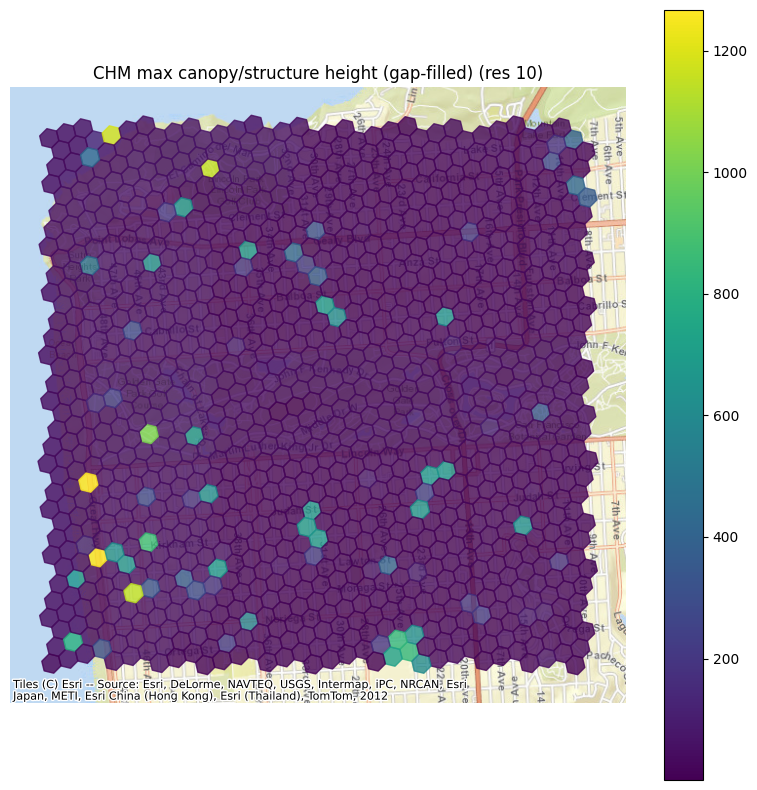

In [0]:
if RENDER_H3:
    # Gap-filled CHM max canopy/structure height. show_cell_map: DEMO -> GGP map; full SF -> compact
    # SF overview + GGP detail.
    show_cell_map(spark.table(_tbl("wc_h3", "chm", H3_RESOLUTION)), "max_chm_z",
                  "CHM max canopy/structure height (gap-filled)", cmap="viridis")


## Composite and comparison renders

Ties the pipeline together with three multi-layer renders:

1. **CHM raster + H3 overlay** — a 1 m-pixel canopy surface tile composited with
   the H3-gridded max canopy heights, showing how the hexagonal aggregation
   approximates the raw pixel surface at coarser resolution.
2. **DEM vs DSM side-by-side** — bare-earth vs surface elevation bands in one
   figure to highlight where buildings and canopy push DSM above DEM.
3. **LiDAR point cloud narrative** — the raw RGB-colored input that feeds
   nb1/nb2a, connecting the source point cloud to the H3-gridded outputs above.

Composite saved: /Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/chm_composite_t5.png | window tx 6..7, ty 9..10 | 4 raster tile(s), 195 H3 cells


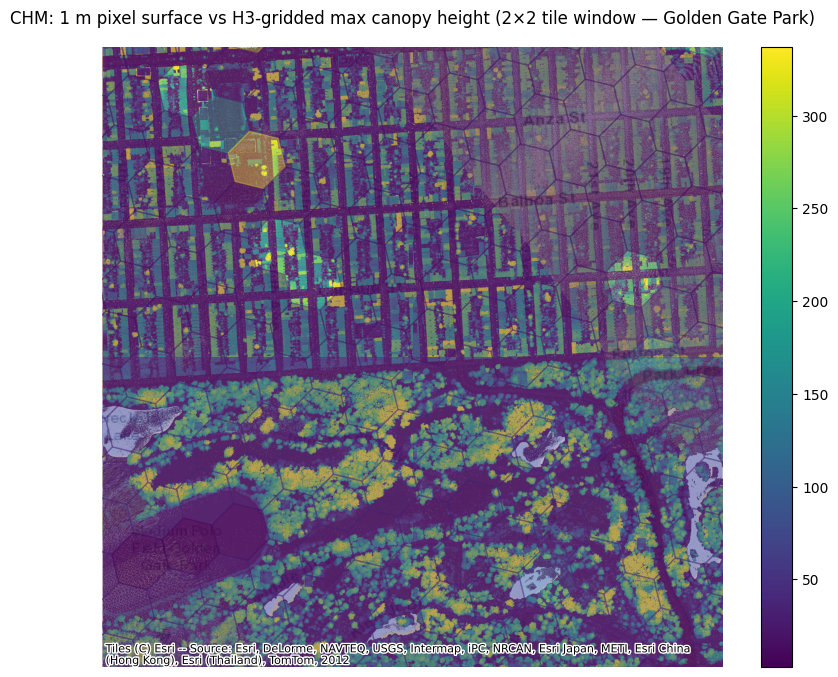

In [0]:
if RENDER_H3:
    # --- CHM 1 m-pixel surface vs H3 max canopy — SAME window + colormap ---
    # Both layers cover one identical 2×2-tile window around Golden Gate Park: the 1 m-pixel
    # CHM raster (mosaicked across the window tiles) UNDER the H3-gridded max canopy heights
    # clipped to the same window. Both use viridis on the artifact-cleaned CHM (<= MAX_CHM_M),
    # so a hex reads as the same color as the pixels it summarizes; the hexes are a
    # semi-transparent 0.35 overlay over the prominent 0.85 raster, so the pixel surface shows
    # through. (The raw chm_h3 would let >MAX_CHM_M LiDAR artifacts blow out the color scale
    # and crush real canopy to one flat color — chm_h3_clean removes them.)
    WIN_TILES = 2   # tiles per side → a 2×2 (~2 km) window around Golden Gate Park
    _gx2, _gy2 = lonlat_to_3857(-122.486, 37.769)
    _tx2, _ty2 = int((_gx2 - X0) / TILE_M), int((_gy2 - Y0) / TILE_M)
    _wx0, _wx1 = X0 + _tx2 * TILE_M, X0 + (_tx2 + WIN_TILES) * TILE_M
    _wy0, _wy1 = Y0 + _ty2 * TILE_M, Y0 + (_ty2 + WIN_TILES) * TILE_M

    # Raster mosaic: every demo CHM tile inside the window (label only the first).
    _ras = []
    for _tx in range(_tx2, _tx2 + WIN_TILES):
        for _ty in range(_ty2, _ty2 + WIN_TILES):
            _row = chm.where((F.col("tx") == _tx) & (F.col("ty") == _ty)).first()
            if _row is not None:
                _ras.append(raster_layer(
                    _row["chm"], band=1, cmap="viridis", opacity=0.85,
                    label="CHM 1 m pixel (max canopy ht, m)" if not _ras else None,
                ))

    # H3 cells: artifact-cleaned (<= MAX_CHM_M), clipped to the SAME window.
    chm_cells_gdf = cells_as_gdf(
        chm_h3_clean, "cellid", extra_cols=["max_chm_z"], dissolve_engine="product"
    )
    chm_cells_win = chm_cells_gdf.to_crs(3857).cx[_wx0:_wx1, _wy0:_wy1]

    if _ras:
        _composite_ax = plot_static(
            _ras + [
                vector_layer(chm_cells_win, geom_col="geometry", column="max_chm_z",
                             cmap="viridis", opacity=0.35,
                             label=f"H3 res {H3_RESOLUTION} (max canopy ht, m)"),
            ],
            title=(f"CHM: 1 m pixel surface vs H3-gridded max canopy height "
                   f"({WIN_TILES}×{WIN_TILES} tile window — Golden Gate Park)"),
        )
        # Frame the axes to the window so both layers fill it (no empty margin).
        _composite_ax.set_xlim(_wx0, _wx1)
        _composite_ax.set_ylim(_wy0, _wy1)
        # Size the colorbar to the (equal-aspect) map so it does not overrun the
        # plot into the title: geopandas' legend sizes it to the taller subplot
        # area, not the square map. Draw once to realise the aspect box, then match.
        _composite_ax.figure.canvas.draw()
        _cbars = [a for a in _composite_ax.figure.axes if a is not _composite_ax]
        if _cbars:
            _mb = _composite_ax.get_position()
            _cb = _cbars[-1].get_position()
            _cbars[-1].set_position([_cb.x0, _mb.y0, _cb.width, _mb.height])
        _composite_png = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/chm_composite_t5.png"
        _composite_ax.figure.savefig(_composite_png, dpi=150, bbox_inches="tight")
        print(f"Composite saved: {_composite_png} | window tx {_tx2}..{_tx2 + WIN_TILES - 1}, "
              f"ty {_ty2}..{_ty2 + WIN_TILES - 1} | {len(_ras)} raster tile(s), "
              f"{len(chm_cells_win)} H3 cells")
    else:
        print(f"No CHM tiles in window tx {_tx2}..{_tx2 + WIN_TILES - 1}, "
              f"ty {_ty2}..{_ty2 + WIN_TILES - 1} — skipped.")

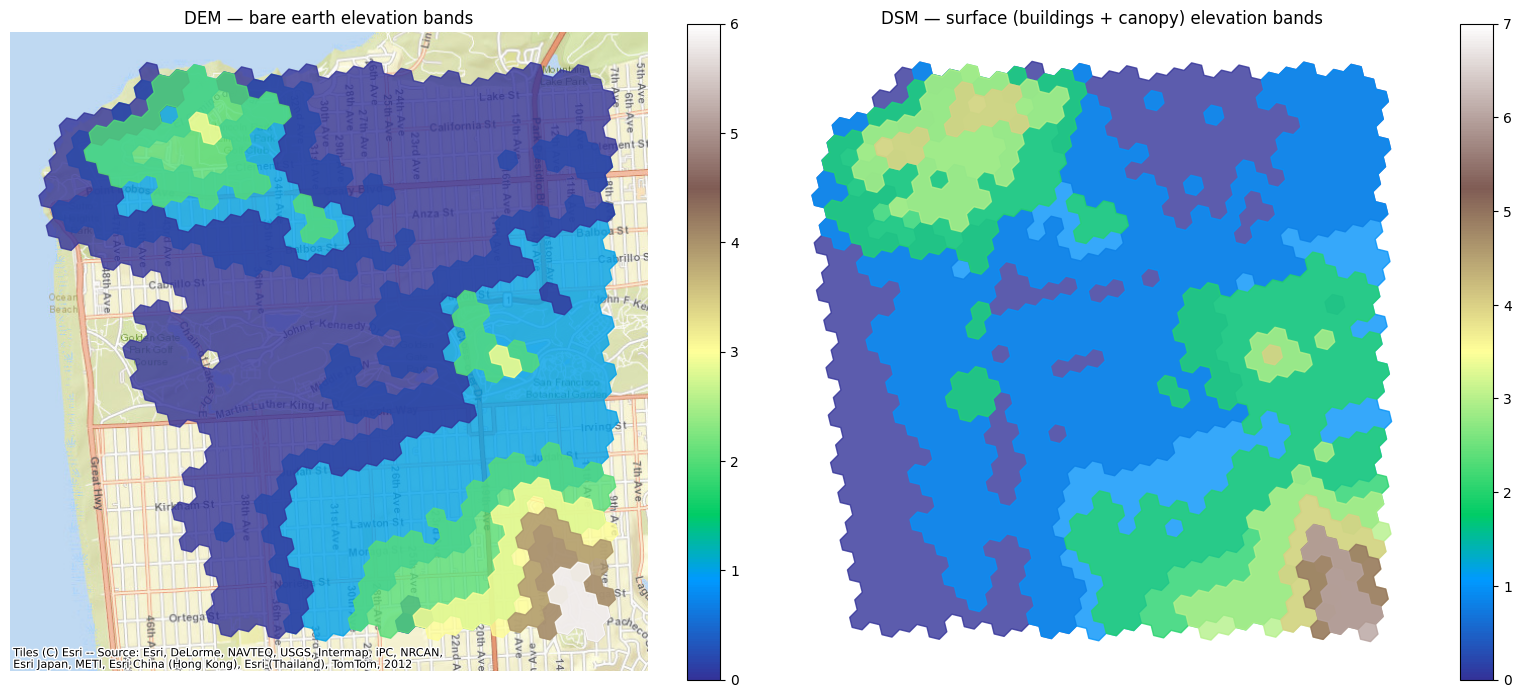

In [0]:
if RENDER_H3:
    # --- DEM vs DSM H3 cells side-by-side ---
    # Elevation bands from the bare-earth DTM (DEM) and the surface model (DSM,
    # which includes buildings and canopy) in one figure.  Cells where DSM exceeds DEM
    # reveal structure and vegetation height above bare ground.
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    dem_gdf = cells_as_gdf(
        dem_h3, "cellid", extra_cols=["band_level"],
        dissolve_by="band_level", dissolve_engine="product",
    )
    dsm_gdf = cells_as_gdf(
        dsm_h3, "cellid", extra_cols=["band_level"],
        dissolve_by="band_level", dissolve_engine="product",
    )
    plot_static(dem_gdf, column="band_level", cmap="terrain",
                title="DEM — bare earth elevation bands", ax=axes[0])
    plot_static(dsm_gdf, column="band_level", cmap="terrain",
                title="DSM — surface (buildings + canopy) elevation bands",
                ax=axes[1], basemap=False)
    plt.tight_layout()


## Full-SF scale-up and profiling

Runs the complete San Francisco AOI (`DEMO=False`, all tiles at H3 res 10). Each H3-gridding path is timed independently. Paths that exceed the 30-minute budget are reported, so you can plan a larger cluster or a coarser resolution for very large AOIs.

Expected timings on Serverless (env 6):
- DEM/DSM isoband path: 5–20 min (all tiles × isoband + optional st_simplify + h3_try_coverash3; default SIMPLIFY=True keeps this in budget)
- CHM rastertogridmax: 5–15 min (all tiles × LATERAL UDTF)
- cellfill: < 2 min (driver-side aggregation over ~1 150 cells)

> **Opt-in.** These cells run only when `RUN_FULL_SF=True` (set in the overrides cell). The default demo path leaves them inert so a demo iteration never pays for a full-SF rebuild.

In [0]:
if RUN_FULL_SF:
    # ── FULL-SF SCALE-UP — rebuilds tables at full SF scale ───────────────────────────
    # This sets DEMO=False and FORCE_RELOAD=True, then calls _persist() for each surface —
    # which runs saveAsTable.  Reported timings INCLUDE the Delta write (not compute-only).
    # The cells above are the demo-scale build; this is the full-SF overwrite.
    # A double full-SF build only occurs when DEMO=False is injected globally for the whole
    # notebook run (intentional — used for profiling; understood as a 2× cost).
    # Expected timings at H3 res 10 over all of SF on Serverless:
    #   DEM/DSM isoband path:  5–20 min (336 tiles × isoband + h3_try_coverash3)
    #   CHM rastertogridmax:   5–15 min (336 tiles × LATERAL UDTF)
    #   cellfill:              < 2 min  (driver-side aggregation over ~1,150 cells)
    # Paths slower than the time budget below are reported (not failures).
    DEMO = False
    FORCE_RELOAD = True    # T9 profiles compute via _persist() write — uses repartition fix
    # Re-read source tables under DEMO=False so _tbl() resolves full (non-demo) table names.
    dtm_in = spark.table(_tbl(SRC_PREFIX, "dtm"))
    dsm_in = spark.table(_tbl(SRC_PREFIX, "dsm"))
    chm_in = spark.table(_tbl(SRC_PREFIX, "chm"))  # full tile sets
    print(f"Full-SF: {dtm_in.count()} DTM | {dsm_in.count()} DSM | {chm_in.count()} CHM tiles")

In [0]:
if RUN_FULL_SF:
    import time
    t0 = time.time()
    dem_cells_full = _surface_to_h3_cells(dtm_in, "dtm", breaks_arr, H3_RESOLUTION, land_wkb, simplify=SIMPLIFY)
    dem_h3_full    = _persist(with_join_parent(dem_cells_full), "dem", res=H3_RESOLUTION)   # → wc_h3_dem_res10; repartition fix prevents OOM
    dem_elapsed    = time.time() - t0
    dem_count      = dem_h3_full.count()
    print(f"DEM full-SF: {dem_count} H3 cells in {dem_elapsed:.1f}s "
          f"({dem_count / dem_elapsed:.0f} cells/s)")
    assert dem_count > 500, f"Expected >500 DEM H3 cells at res 10 over full SF, got {dem_count}"

In [0]:
if RUN_FULL_SF:
    t0 = time.time()
    dsm_cells_full = _surface_to_h3_cells(dsm_in, "dsm", breaks_arr, H3_RESOLUTION, land_wkb, simplify=SIMPLIFY)
    dsm_h3_full    = _persist(with_join_parent(dsm_cells_full), "dsm", res=H3_RESOLUTION)   # → wc_h3_dsm_res10; repartition fix prevents OOM
    dsm_elapsed    = time.time() - t0
    dsm_count      = dsm_h3_full.count()
    print(f"DSM full-SF: {dsm_count} H3 cells in {dsm_elapsed:.1f}s")
    assert dsm_count > 500, f"Expected >500 DSM H3 cells, got {dsm_count}"

In [0]:
if RUN_FULL_SF:
    t0 = time.time()
    # repartition(64, 'tx') here matches the DEMO cell; 512 is handled inside
    # _surface_to_h3_cells for DEM/DSM; CHM uses a direct SQL path so we keep
    # the explicit repartition here.
    chm_4326_full = chm_in.select(
        "tx", "ty", rx.rst_transform("chm", F.lit(4326)).alias("chm_4326")
    ).repartition(512, "tx", "ty")
    chm_4326_full.createOrReplaceTempView("chm_4326_tiles_full")
    # ANSI LATERAL form (verified schema: band INT, cellID LONG, measure DOUBLE).
    chm_cells_full = spark.sql(f"""
        SELECT t.cellID AS cellid, t.measure AS chm_z
        FROM   chm_4326_tiles_full,
               LATERAL gbx_rst_h3_rastertogridmax(chm_4326, {H3_RESOLUTION}) t
        WHERE  t.band = 1
    """).groupBy("cellid").agg(F.max("chm_z").alias("max_chm_z")) \
       .withColumn("res", F.lit(H3_RESOLUTION))
    chm_h3_full   = _persist(with_join_parent(chm_cells_full), "chm", res=H3_RESOLUTION)   # → wc_h3_chm_res10; repartition prevents OOM
    chm_elapsed   = time.time() - t0
    chm_count     = chm_h3_full.count()
    print(f"CHM full-SF: {chm_count} H3 cells in {chm_elapsed:.1f}s "
          f"({chm_count / chm_elapsed:.0f} cells/s)")
    assert chm_count > 500, f"Expected >500 CHM H3 cells, got {chm_count}"

In [0]:
if RUN_FULL_SF:
    t0 = time.time()
    # MAX_CHM_M clamp applies at full scale (same ceiling as the demo path above).
    chm_h3_full_clean = chm_h3_full.where(F.col("max_chm_z") <= MAX_CHM_M)
    chm_filled_full = _cellfill_depth(chm_h3_full_clean.select("cellid", "max_chm_z"), "max_chm_z")
    chm_filled_land_full = chm_filled_full.join(land_cells, "cellid", "inner")
    fill_elapsed = time.time() - t0
    print(f"CHM cellfill full-SF: {chm_h3_full_clean.count()} → {chm_filled_land_full.count()} cells "
          f"in {fill_elapsed:.1f}s")

In [0]:
if RUN_FULL_SF:
    print("| Path | Tiles | Output cells | Wall-clock (s) |")
    print("|------|-------|-------------|----------------|")
    print(f"| DEM isoband→H3  | {dtm_in.count()} | {dem_count}  | {dem_elapsed:.0f} |")
    print(f"| DSM isoband→H3  | {dsm_in.count()} | {dsm_count}  | {dsm_elapsed:.0f} |")
    print(f"| CHM rastertogridmax | {chm_in.count()} | {chm_count} | {chm_elapsed:.0f} |")
    print(f"| CHM cellfill    | —     | {chm_filled_land_full.count()} | {fill_elapsed:.0f} |")

In [0]:
if RUN_FULL_SF:
    SLOW_PATH_S = 1800   # 30 min — note any path slower than this at full-SF scale
    _slow = []
    if dem_elapsed > SLOW_PATH_S:
        _slow.append(f"DEM/DSM isoband → H3: {dem_elapsed:.0f}s")
    if chm_elapsed > SLOW_PATH_S:
        _slow.append(f"CHM rastertogridmax: {chm_elapsed:.0f}s")
    if fill_elapsed > 120:
        _slow.append(f"CHM cellfill: {fill_elapsed:.0f}s")
    if _slow:
        print("Full-SF paths over the time budget — for very large AOIs consider a larger")
        print("cluster or a coarser H3 resolution:")
        for _s in _slow:
            print(f"  - {_s}")
    else:
        print("Full-SF scale-up complete — all paths within the time budget.")

In [0]:
if RUN_FULL_SF and RENDER_H3:
    # Full-SF DEM: filter to band_level >= 1 (elevation >= 30 m) to suppress the
    # near-sea-level band that creates a too-dense scatter at full SF scale.
    dem_gdf_full = cells_as_gdf(
        dem_h3_full.where(F.col("band_level") >= 1), "cellid", extra_cols=["band_level"],
        dissolve_by="band_level", dissolve_engine="product",
    )
    plot_static(dem_gdf_full, column="band_level", cmap="terrain",
                title=f"Full SF — DEM elevation bands ≥ 30 m, H3 res {H3_RESOLUTION}")

    # Full-SF CHM: filter to max_chm_z >= 200 m to show only the tallest structures
    # (downtown towers, etc.) and avoid the low-value scatter across the flat city grid.
    chm_gdf_full = cells_as_gdf(
        chm_h3_full.where(F.col("max_chm_z") >= 200), "cellid", extra_cols=["max_chm_z"],
        dissolve_engine="product",
    )
    plot_static(chm_gdf_full, column="max_chm_z", cmap="viridis",
                title=f"Full SF — CHM canopy height ≥ 200 m, H3 res {H3_RESOLUTION}")
